In [ ]:
from google.colab import drive
import pickle
import numpy as np
import os

drive.mount('/content/drive')

def load_batch(file_path):
    with open(file_path, 'rb') as f:
        dict_data = pickle.load(f, encoding='bytes')
        features = dict_data[b'data']
        labels = dict_data[b'labels']
        features = features.reshape((len(features), 3, 32, 32)).transpose(0, 2, 3, 1)
        return features, labels

def load_full_dataset(path):
    x_train, y_train = [], []
    for i in range(1, 6):
        batch_path = os.path.join(path, f'data_batch_{i}')
        features, labels = load_batch(batch_path)
        x_train.append(features)
        y_train.extend(labels)

    x_train = np.concatenate(x_train)
    y_train = np.array(y_train).reshape(-1, 1)

    test_batch_path = os.path.join(path, 'test_batch')
    x_test, y_test = load_batch(test_batch_path)
    x_test = x_test
    y_test = np.array(y_test).reshape(-1, 1)

    return (x_train, y_train), (x_test, y_test)

dataset_path = '/content/drive/MyDrive/cifar-10-batches-py'

(x_train, y_train), (x_test, y_test) = load_full_dataset(dataset_path)

x_train = x_train / 255.0
x_test = x_test / 255.0

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

Mounted at /content/drive
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


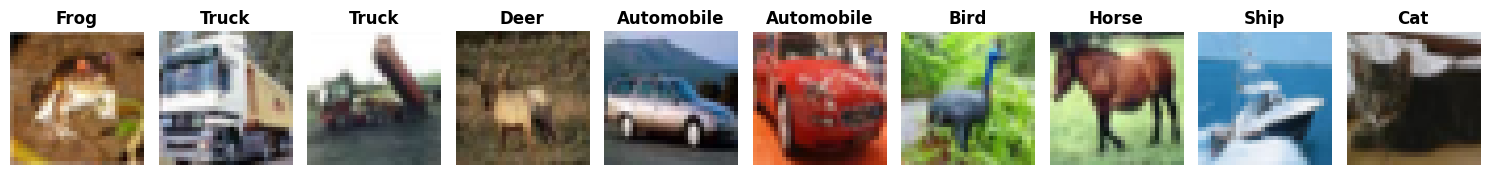

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import os

# Convert labels to one-hot encoding for Categorical Crossentropy loss
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

def plot_sample_images(x_data, y_data, class_labels, num_images=10, save_path='sample_images.eps'):
    """Displays and saves sample images from the dataset."""
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i in range(num_images):
        axes[i].imshow(x_data[i])
        # Retrieve the original integer label
        label_idx = int(y_data[i][0])
        axes[i].set_title(class_labels[label_idx], fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, format='eps', dpi=600, bbox_inches='tight')
    plt.show()

# Execute Task 1 Visualization
plot_sample_images(x_train, y_train, class_names)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

def build_transfer_learning_model(input_shape=(32, 32, 3), num_classes=10):
    """Constructs the VGG16 transfer learning model."""
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

vgg_model, vgg_base = build_transfer_learning_model()

# Task 3: Model Training Configuration
vgg_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("Starting initial training on frozen base (20 epochs)...")
history_initial = vgg_model.fit(
    x_train, y_train_cat,
    batch_size=32,
    epochs=20,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

Starting initial training on frozen base (20 epochs)...
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.5248 - loss: 1.3705 - val_accuracy: 0.5675 - val_loss: 1.2479
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5843 - loss: 1.1896 - val_accuracy: 0.5738 - val_loss: 1.2185
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6026 - loss: 1.1319 - val_accuracy: 0.5908 - val_loss: 1.1727
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6187 - loss: 1.0926 - val_accuracy: 0.5894 - val_loss: 1.1737
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6280 - loss: 1.0614 - val_accuracy: 0.6049 - val_loss: 1.1483
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6387 - loss: 1.0325 - val_accuracy: 0.6052 - val_loss: 1.1310
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6489 - loss: 1.0049 - val_accuracy: 0.6043 - val_loss: 1.1344
Epoch 8/20
1563/1563

In [ ]:
def fine_tune_model(model, base_model, learning_rate=1e-5):
    base_model.trainable = True

    for layer in base_model.layers:
        if layer.name.startswith('block5'):
            layer.trainable = True
        else:
            layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

vgg_model = fine_tune_model(vgg_model, vgg_base)

print("\nStarting fine-tuning phase (10 epochs)...")
history_finetune = vgg_model.fit(
    x_train, y_train_cat,
    batch_size=32,
    epochs=10,
    validation_data=(x_test, y_test_cat),
    verbose=1
)


Starting fine-tuning phase (10 epochs)...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.7356 - loss: 0.7416 - val_accuracy: 0.6457 - val_loss: 1.0822
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.7920 - loss: 0.5931 - val_accuracy: 0.6680 - val_loss: 1.0414
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8284 - loss: 0.4962 - val_accuracy: 0.6773 - val_loss: 1.0289
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8574 - loss: 0.4177 - val_accuracy: 0.6848 - val_loss: 1.0169
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8836 - loss: 0.3526 - val_accuracy: 0.6856 - val_loss: 1.0195
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9033 - loss: 0.2972 - val_accuracy: 0.6977 - val_loss: 1.0216
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9231 - loss: 0.2454 - val_accuracy: 0.7013 - val_loss: 1.0461
Epoch 8/10
1563/1563 ━━━━━━━━━━━━

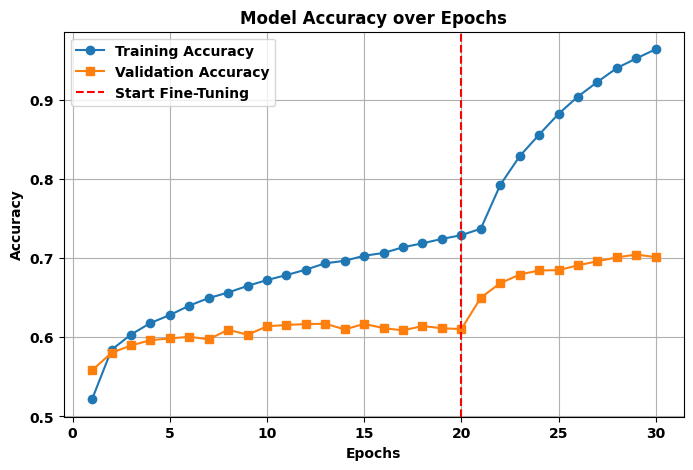

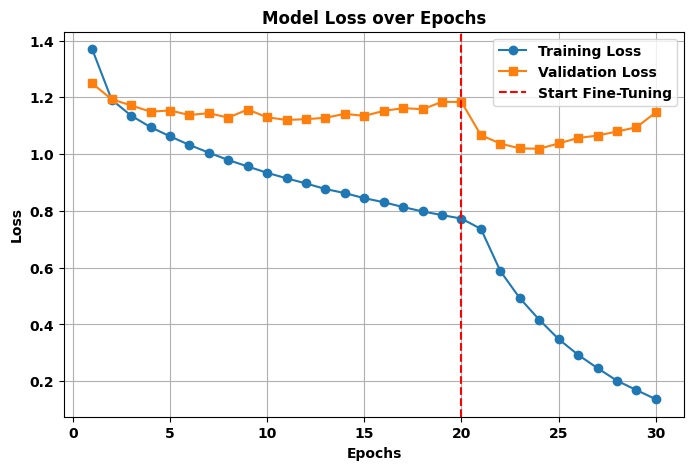

In [ ]:
def plot_training_history(history1, history2, metric='accuracy', save_path='training_curve.eps'):
    """Plots training and validation metrics across both training phases."""
    plt.figure(figsize=(8, 5))

    train_metrics = history1.history[metric] + history2.history[metric]
    val_metrics = history1.history['val_' + metric] + history2.history['val_' + metric]
    epochs = range(1, len(train_metrics) + 1)

    plt.plot(epochs, train_metrics, label=f'Training {metric.capitalize()}', marker='o')
    plt.plot(epochs, val_metrics, label=f'Validation {metric.capitalize()}', marker='s')

    plt.axvline(x=len(history1.history[metric]), color='red', linestyle='--', label='Start Fine-Tuning')

    plt.title(f'Model {metric.capitalize()} over Epochs', fontweight='bold')

    # Bold Axes Labels
    plt.xlabel('Epochs', fontweight='bold')
    plt.ylabel(metric.capitalize(), fontweight='bold')

    # Bold Tick Labels
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')

    # Bold Legend Texts
    legend = plt.legend()
    for text in legend.get_texts():
        text.set_weight('bold')

    plt.grid(True)
    plt.savefig(save_path, format='eps', dpi=600, bbox_inches='tight')
    plt.show()

plot_training_history(history_initial, history_finetune, metric='accuracy', save_path='train_val_accuracy.eps')
plot_training_history(history_initial, history_finetune, metric='loss', save_path='train_val_loss.eps')

In [ ]:
import time
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD

# Define hyperparameter configurations based on Section 16 of the lab manual.
# We establish a baseline and vary parameters to isolate their effects.
experiments = [
    {'lr': 0.001,  'batch': 32, 'epochs': 10, 'opt': 'Adam', 'dense': 128, 'freeze': 'All'},     # Baseline
    {'lr': 0.0001, 'batch': 32, 'epochs': 10, 'opt': 'Adam', 'dense': 128, 'freeze': 'All'},     # Lower LR
    {'lr': 0.001,  'batch': 64, 'epochs': 10, 'opt': 'Adam', 'dense': 128, 'freeze': 'All'},     # Larger Batch
    {'lr': 0.001,  'batch': 32, 'epochs': 10, 'opt': 'SGD',  'dense': 128, 'freeze': 'All'},     # Different Optimizer
    {'lr': 0.001,  'batch': 32, 'epochs': 10, 'opt': 'Adam', 'dense': 256, 'freeze': 'All'},     # Increased Dense Units
    {'lr': 0.001,  'batch': 32, 'epochs': 10, 'opt': 'Adam', 'dense': 128, 'freeze': 'Partial'}  # Partial Freeze (Fine-Tuning)
]

results = []

for idx, exp in enumerate(experiments):
    print(f"Running Experiment {idx + 1}/{len(experiments)}: {exp}")

    # 1. Build the Base Model
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

    # 2. Apply Freeze Logic
    if exp['freeze'] == 'All':
        base_model.trainable = False
    elif exp['freeze'] == 'Partial':
        base_model.trainable = True
        for layer in base_model.layers:
            if not layer.name.startswith('block5'):
                layer.trainable = False

    # 3. Construct the Classification Head
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(exp['dense'], activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    # 4. Configure the Optimizer
    if exp['opt'] == 'Adam':
        optimizer = Adam(learning_rate=exp['lr'])
    else:
        optimizer = SGD(learning_rate=exp['lr'])

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # 5. Train and Track Time
    start_time = time.time()
    history = model.fit(
        x_train, y_train_cat,
        batch_size=exp['batch'],
        epochs=exp['epochs'],
        validation_data=(x_test, y_test_cat),
        verbose=0 # Output suppressed to keep the notebook clean during loop execution
    )
    training_time = time.time() - start_time

    # 6. Store the Evaluation Metrics
    results.append({
        'Learning Rate': exp['lr'],
        'Batch Size': exp['batch'],
        'Epochs': exp['epochs'],
        'Optimizer': exp['opt'],
        'Dense Units': exp['dense'],
        'Frozen Layers': exp['freeze'],
        'Val Accuracy (%)': round(history.history['val_accuracy'][-1] * 100, 2),
        'Time (s)': round(training_time, 2)
    })

# Display the comparative results in a tabular format
results_df = pd.DataFrame(results)
print("\n--- Hyperparameter Study Results ---")
print(results_df.to_string(index=False))

Running Experiment 1/6: {'lr': 0.001, 'batch': 32, 'epochs': 10, 'opt': 'Adam', 'dense': 128, 'freeze': 'All'}
Running Experiment 2/6: {'lr': 0.0001, 'batch': 32, 'epochs': 10, 'opt': 'Adam', 'dense': 128, 'freeze': 'All'}
Running Experiment 3/6: {'lr': 0.001, 'batch': 64, 'epochs': 10, 'opt': 'Adam', 'dense': 128, 'freeze': 'All'}
Running Experiment 4/6: {'lr': 0.001, 'batch': 32, 'epochs': 10, 'opt': 'SGD', 'dense': 128, 'freeze': 'All'}
Running Experiment 5/6: {'lr': 0.001, 'batch': 32, 'epochs': 10, 'opt': 'Adam', 'dense': 256, 'freeze': 'All'}
Running Experiment 6/6: {'lr': 0.001, 'batch': 32, 'epochs': 10, 'opt': 'Adam', 'dense': 128, 'freeze': 'Partial'}

--- Hyperparameter Study Results ---
 Learning Rate  Batch Size  Epochs Optimizer  Dense Units Frozen Layers  Val Accuracy (%)  Time (s)
        0.0010          32      10      Adam          128           All             61.37    166.60
        0.0001          32      10      Adam          128           All             57.83   

In [ ]:
import time
import pandas as pd
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, InceptionV3

def build_lenet5(input_shape=(32, 32, 3), num_classes=10):
    """Constructs a standard LeNet-5 architecture."""
    model = Sequential([
        Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=input_shape),
        AveragePooling2D(pool_size=(2, 2)),
        Conv2D(16, kernel_size=(5, 5), activation='relu'),
        AveragePooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(120, activation='relu'),
        Dense(84, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name="LeNet-5")
    return model

def build_alexnet_cifar(input_shape=(32, 32, 3), num_classes=10):
    """Constructs a scaled-down AlexNet architecture suitable for 32x32 images."""
    model = Sequential([
        Conv2D(48, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        Conv2D(192, kernel_size=(3, 3), activation='relu', padding='same'),
        Conv2D(192, kernel_size=(3, 3), activation='relu', padding='same'),
        Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name="AlexNet_Scaled")
    return model

def build_resnet50_tl(input_shape=(32, 32, 3), num_classes=10):
    """Constructs a ResNet50 Transfer Learning model."""
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs, name="ResNet50_TL")
    return model

def build_googlenet_proxy_tl(input_shape=(75, 75, 3), num_classes=10):
    """
    Constructs an Inception model (GoogleNet successor).
    Note: InceptionV3 requires inputs to be at least 75x75.
    If using this, x_train/x_test must be resized using tf.image.resize.
    """
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=outputs, name="GoogleNet(Inception)_TL")
    return model

# ---------------------------------------------------------
# Corrected Execution pipeline for Comparison
# ---------------------------------------------------------

models_to_evaluate = [
    build_lenet5(),
    build_alexnet_cifar(),
    vgg_model, # Carried over from Task 2/3
    build_resnet50_tl()
]

comparison_results = []

for model in models_to_evaluate:
    print(f"\nEvaluating Architecture: {model.name}")

    # Correctly identify the vgg_model by object identity to skip retraining
    if model is not vgg_model:
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        start_time = time.time()
        # Train for a minimal baseline to get metrics for the table
        model.fit(x_train, y_train_cat, batch_size=64, epochs=5, verbose=0)
        training_time = time.time() - start_time
    else:
        # VGG16 data placeholder from earlier execution
        training_time = "Recorded in Task 3"

    # Evaluate
    _, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    comparison_results.append({
        'Architecture': model.name,
        'Parameters': f"{model.count_params():,}",
        'Accuracy (%)': round(test_acc * 100, 2),
        'Training Time (s)': round(training_time, 2) if isinstance(training_time, float) else training_time
    })

# Output Table for Section 18.2
comparison_df = pd.DataFrame(comparison_results)
print("\n--- 18.2 Comparison of CNN Architectures ---")
print(comparison_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Evaluating Architecture: LeNet-5

Evaluating Architecture: AlexNet_Scaled

Evaluating Architecture: functional_10

Evaluating Architecture: ResNet50_TL

--- 18.2 Comparison of CNN Architectures ---
  Architecture Parameters  Accuracy (%)  Training Time (s)
       LeNet-5     62,006         56.81              19.55
AlexNet_Scaled  2,014,410         72.39              44.04
 functional_10 14,781,642         70.05 Recorded in Task 3
   ResNet50_TL 23,851,274         37.87              51.56


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


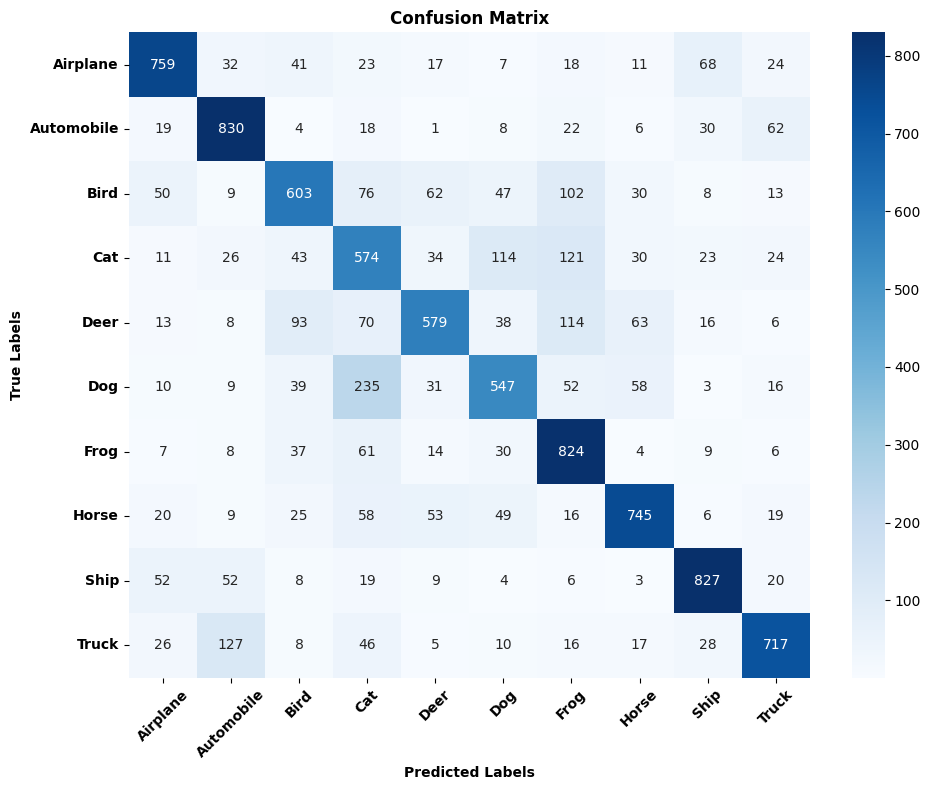

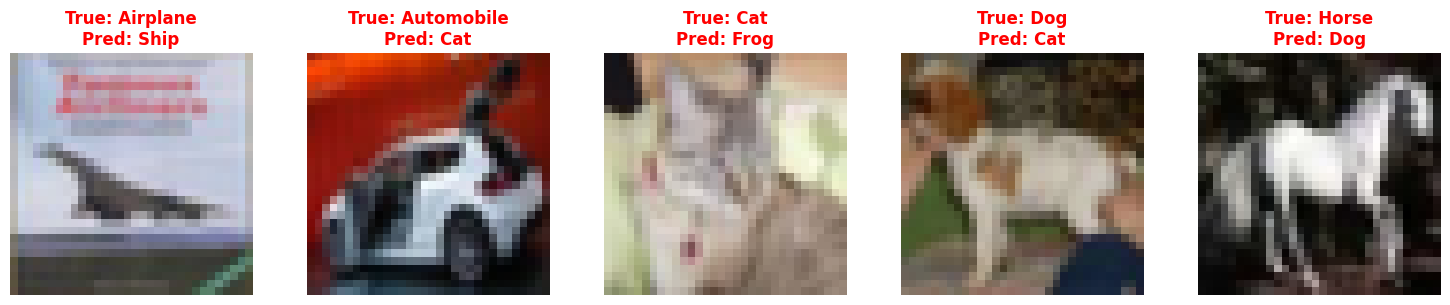

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure predictions are generated (if not already done in your notebook)
y_pred_probs = vgg_model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = y_test.flatten()

# ---------------------------------------------------------
# 1. Plot: Confusion Matrix
# ---------------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, classes, save_path='confusion_matrix.eps'):
    """Generates, displays, and saves the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)

    plt.title('Confusion Matrix', fontweight='bold')
    plt.xlabel('Predicted Labels', fontweight='bold')
    plt.ylabel('True Labels', fontweight='bold')

    plt.xticks(fontweight='bold', rotation=45)
    plt.yticks(fontweight='bold', rotation=0)

    plt.tight_layout()
    plt.savefig(save_path, format='eps', dpi=600, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_true_classes, y_pred_classes, class_names)

# ---------------------------------------------------------
# 2. Plot: Misclassified Images
# ---------------------------------------------------------
def plot_misclassified_images(x_data, y_true, y_pred, classes, num_images=5, save_path='misclassified.eps'):
    """Finds, displays, and saves a sample of misclassified images."""
    # Find indices where the prediction does not match the true label
    misclassified_idx = np.where(y_true != y_pred)[0]

    # Select a subset of misclassified images
    sample_idx = misclassified_idx[:num_images]

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i, idx in enumerate(sample_idx):
        axes[i].imshow(x_data[idx])

        true_label = classes[y_true[idx]]
        pred_label = classes[y_pred[idx]]

        # Display True vs Predicted in the title
        title_text = f"True: {true_label}\nPred: {pred_label}"
        axes[i].set_title(title_text, fontweight='bold', color='red')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, format='eps', dpi=600, bbox_inches='tight')
    plt.show()

plot_misclassified_images(x_test, y_true_classes, y_pred_classes, class_names)